# Прогноз спроса BikeSouth: нелинейные модели

**Цель проекта:**
Разработать и оценить нелинейную модель машинного обучения для прогнозирования почасового спроса на аренду велосипедов BikeSouth на основе погодных и календарных факторов, чтобы повысить точность прогноза по сравнению с базовой линейной моделью.

**Задачи проекта:**
1. Проанализировать исходные данные и baseline-модель заказчика: изучить структуру датасетов, проверить качество данных, провести EDA и оценить метрики готовой линейной регрессии.
2. Построить и оптимизировать нелинейные модели: подготовить данные, создать необходимые признаки, обучить kNN Regressor и Decision Tree Regressor, а также подобрать гиперпараметры с помощью Optuna по метрике RMSE.
3. Выбрать лучшую модель и оценить её качество: сравнить модели по RMSE, MAE и R², проверить финальную модель на тестовой выборке, интерпретировать важность признаков и сформулировать рекомендации для BikeSouth.

**Предоставленные данные:**
| Признак | Описание | Единица измерения / Значения |
|----------|----------|------------------------------|
| Temperature | Температура воздуха | °C |
| Humidity | Относительная влажность воздуха | % |
| Windspeed | Скорость ветра | м/с |
| Visibility | Видимость | 10 м |
| Dew Point Temperature | Температура точки росы | °C |
| Solar Radiation | Солнечная радиация | MJ/м² |
| Rainfall | Количество осадков | мм |
| Snowfall | Количество снега | см |
| Seasons | Время года | Winter, Spring, Summer, Autumn |
| Holiday | Выходной/праздничный день | Holiday / No Holiday |
| Functioning Day | Рабочий день проката велосипедов | Yes / No |
| Night | Ночной период (00:00–05:59) | True / False |
| Morning | Утренний период (06:00–09:59) | True / False |
| Evening | Вечерний период (16:00–19:59) | True / False |
| Late Evening | Поздний вечер (20:00–23:59) | True / False |
| Daytime | Дневной период (10:00–15:59) — базовое состояние, если все остальные временные признаки = False | Неявно |
| Rented Bike Count | **Целевая переменная** — количество арендованных велосипедов за час | шт. |

## 1. Подготовка среды и загрузка данных

Установим все необходимые зависимости и загрузим данные

In [1]:
# Установка зависимостей
!pip install -q \
  scikit-learn==1.6.1 \
  numpy \
  pandas \
  seaborn \
  phik \
  joblib


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
# Импорт основных библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import phik
import joblib
import optuna

In [3]:
# Random state
RANDOM_STATE=1703

# Целевой признак
TARGET_COL = 'Rented Bike Count'

In [4]:
# Настройка параметров библиотек
mpl.rcParams['figure.constrained_layout.use'] = True

In [5]:
# Настройка автоматической перезагрузки кастомных модулей
%load_ext autoreload
%autoreload 2

In [6]:
# Загрузка датасетов с кешированием на диске
data_files = {
    'train': 'ds_s14_train_data.csv',
    'test': 'ds_s14_test_data.csv',
}

dfs = {}

for file, file_path in data_files.items():
    try:
        dfs[file] = pd.read_csv(f'./{file}.csv')
        print(f'Dataset {file} found locally.')
    except:
        print(f'Dataset {file} not found locally.')
        dfs[file] = pd.read_csv(f'https://code.s3.yandex.net/datasets/{file_path}')
        dfs[file].to_csv(f'./{file}.csv', index=False)

Dataset train found locally.
Dataset test found locally.


In [7]:
# Проверка размеров загруженных данных
dfs['train'].shape, dfs['test'].shape

((7008, 16), (1752, 16))

In [8]:
# Для удобства работы с данными, переместим данные в отдельные переменные
df = dfs['train']
df_test = dfs['test']

In [9]:
# Просмотр первых 5 строк датасета
df.head(5)

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


In [10]:
# Просмотр первых 5 строк датасета с тестовыми данными
df_test.head(5)

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005


In [11]:
# Скачивание базовой модели
import os
from urllib.request import urlretrieve

BASE_MODEL_PATH = "baseline_linear_regression_pipeline.joblib"

if os.path.isfile(BASE_MODEL_PATH):
    print("Файл уже существует")
else:
    print("Скачивание файла...")
    urlretrieve('https://code.s3.yandex.net/data-scientist/baseline_linear_regression_pipeline.joblib', BASE_MODEL_PATH)

Файл уже существует


In [12]:
# Загрузка базовой модели
model_base = joblib.load(BASE_MODEL_PATH)
model_base

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['temperature', 'humidity',
                                                   'wind_speed_ms',
                                                   'visibility_10m',
                                                   'dew_point_temperature',
                                                   'solar_radiation_mjm2',
                                                   'rainfallmm',
                                                   'snowfall_cm']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['seasons', 'holiday',
                                                   'functioning_day']),
                                                 ('time', 'passthrough',
                                                  ['time_period_evening',
                                                   'time_period_late_evening',
                                                   'time_period_morning',
                                                   'time_period_night'])])),
                ('model', LinearRegression())])

**Промежуточный вывод**
Выполнены следующие действия для дальнейшей работы:
- Все необходимые зависимости установлены. Частоиспользуемые зависимости сразу импортированы
- Определена общая константа для единого random_state 
- Тренировочные и тестовые данные загружены
- Базовая модель загружена

Можно переходить к анализу базовой модели

## 2. Анализ baseline-модели BikeSouth

Замерим ключевые метрики на базовой модели с помощью кросс-валидации

Для начала посмотрим из чего состоит базовая модель и какие признаки требует для работы

In [13]:
# Структура базовой модели
model_base.named_steps

{'preprocessor': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  ['temperature', 'humidity', 'wind_speed_ms',
                                   'visibility_10m', 'dew_point_temperature',
                                   'solar_radiation_mjm2', 'rainfallmm',
                                   'snowfall_cm']),
                                 ('cat',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('onehot',
                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 sparse_output=False

In [14]:
# Получение списка признаков, которые требует ColumnTransformer из базовой модели
np.concatenate([
    x[2]
    for x
    in model_base.named_steps['preprocessor'].transformers
]).tolist()


['temperature',
 'humidity',
 'wind_speed_ms',
 'visibility_10m',
 'dew_point_temperature',
 'solar_radiation_mjm2',
 'rainfallmm',
 'snowfall_cm',
 'seasons',
 'holiday',
 'functioning_day',
 'time_period_evening',
 'time_period_late_evening',
 'time_period_morning',
 'time_period_night']

In [15]:
df.columns.tolist()

['Temperature',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'Seasons',
 'Holiday',
 'Functioning Day',
 'Time_Period_Evening',
 'Time_Period_Late Evening',
 'Time_Period_Morning',
 'Time_Period_Night',
 'Rented Bike Count']

Имена признаков, которые требует базовая модель, и, которые переданы для нам для работы, отличаются. Поэтому напишем кастомный трансформер для преобразования имен и объединим его в один пайплайн с базовой моделью

In [16]:
# Кастомный трансформер для преобразования имен признаков
from sklearn.base import BaseEstimator, TransformerMixin

class RenameColumnsTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.columns_mapping = {
            "Temperature": "temperature",
            "Humidity(%)": "humidity",
            "Wind speed (m/s)": "wind_speed_ms",
            "Visibility (10m)": "visibility_10m",
            "Dew point temperature": "dew_point_temperature",
            "Solar Radiation (MJ/m2)": "solar_radiation_mjm2",
            "Rainfall(mm)": "rainfallmm",
            "Snowfall (cm)": "snowfall_cm",
            "Seasons": "seasons",
            "Holiday": "holiday",
            "Functioning Day": "functioning_day",
            "Time_Period_Evening": "time_period_evening",
            "Time_Period_Late Evening": "time_period_late_evening",
            "Time_Period_Morning": "time_period_morning",
            "Time_Period_Night": "time_period_night",
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        return X.rename(columns=self.columns_mapping)

In [17]:
# Добавление кастомного трансформера в пайплайн
from sklearn.pipeline import Pipeline

model_base = Pipeline([
    ('rename_columns', RenameColumnsTransformer()),
    ('default_model', model_base)
])

In [18]:
# Инициализация класса для разбиения данных на кросс-валидации
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [19]:
# Объект со списком метрик для оценки модели
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

In [20]:
# Общий объект для хранения метрик
cv_results = pd.DataFrame({
    'rmse': [],
    'mae': [],
    'r2': []
}, index=pd.Index([], name='model'))
cv_results

,rmse,mae,r2
model,,,


In [21]:
# Вспомогательная функция для добавления метрик в общий объект
def add_metrics(model, cv_result, allow_rewrite=False):
    add_metrics_directly(
        model,
        -cv_result['test_rmse'].mean(),
        -cv_result['test_mae'].mean(),
        cv_result['test_r2'].mean(),
        allow_rewrite=allow_rewrite
    )

def add_metrics_directly(model_name, rmse, mae, r2, allow_rewrite=False):
    if (not allow_rewrite) and (model_name in cv_results.index):
        raise ValueError(f"Model {model_name} already exists in cv_results")
        
    cv_results.loc[model_name] = [rmse, mae, r2]
    cv_results.sort_values(
        by=['rmse', 'r2', 'mae'],
        ascending=[True, False, True],
        inplace=True
    )

In [22]:
# Замер метрик базовой модели на тренировочной выборке с прямым вызовом метрик
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df.drop(columns=TARGET_COL)
y = df[TARGET_COL]
y_pred = model_base.predict(X)

add_metrics_directly(
    'base_train',
    mean_squared_error(y, y_pred) ** 0.5,
    mean_absolute_error(y, y_pred),
    r2_score(y, y_pred)
)

In [23]:
# Замер метрик базовой модели на тестовой выборке
X = df_test.drop(columns=TARGET_COL)
y = df_test[TARGET_COL]
y_pred = model_base.predict(X)

add_metrics_directly(
    'base_test',
    mean_squared_error(y, y_pred) ** 0.5,
    mean_absolute_error(y, y_pred),
    r2_score(y, y_pred)
)

In [24]:
# Вывод результатов
cv_results

,rmse,mae,r2
model,,,
base_test,411.454458,312.531298,0.586293
base_train,412.499623,309.152519,0.592596


По результатам оценки базовая модель демонстрирует сопоставимое качество на обучающей и тестовой выборках. Значение коэффициента детерминации R2 составляет 0.59 на обучении и 0.58 на тесте, то есть модель объясняет примерно 58–59% вариации целевой переменной. Средняя абсолютная ошибка (MAE) находится на уровне 310 велосипедов, а среднеквадратичная ошибка (RMSE) — около 413 велосипедов. Таким образом, в среднем прогноз модели отклоняется от фактического значения на 300–400 велосипедов, что указывает на умеренную точность и наличие значительной доли необъяснённой вариации в данных.

Полученный результат будет использоваться как базовый для сравнения с более сложными моделями. Линейная регрессия показывает приемлемое качество и позволяет выявить основные зависимости в данных. Далее будут рассмотрены модели KNN и дерева решений, чтобы оценить возможность повышения точности прогнозирования.

## 3. Исследовательский анализ данных (EDA)

Исследовательский анализ данных будет касаться только тренировочных данных. Тестовые данные будут применены только при конечной оценке моделей

### 3.1 Общая информация о датасете

Вспомним базовую информацию о датасете


In [25]:
# Размер датасета
df.shape

(7008, 16)

In [26]:
# Первые строки датасета
df[:5]

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   str    
 9   Holiday                   7008 non-null   str    
 10  Functioning Day           7008 non-null   str    
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Period_Night  

Описание данных совпадает с полученной информацией. Признаки соответствуют типам, а признак Daytime - отсутствует так как временной период уже закодирован с через OHE с удалением одного столбца

### 3.2 Пропуски

Также уже заметны пропуски. Посмотрим на них подробнее

In [28]:
pd.DataFrame({
    'amount': df.isna().sum(),
    'share': df.isna().sum() / len(df)
})

,amount,share
Temperature,0,0.000000
Humidity(%),250,0.035674
Wind speed (m/s),210,0.029966
Visibility (10m),259,0.036958
Dew point temperature,0,0.000000
Solar Radiation (MJ/m2),210,0.029966
Rainfall(mm),262,0.037386
Snowfall (cm),263,0.037529
Seasons,0,0.000000
Holiday,0,0.000000


Доля пропусков небольшая. В пайплане работы модели предусмотрим заполнение пропусков для всех признаков, чтобы модель могла стабильно работать с данными, в которых есть пропуски

### 3.3 Дубликаты
Проверим датасет на наличие дубликатов

In [29]:
df.duplicated().sum()

np.int64(0)

Явных дубликатов не выявлено. 

Неявные дубликаты могут возникнуть из-за строковых/категориальных признаков с разным форматированием значений. Посмотрим на уникальные значения таких признаков

In [30]:
# Проверка значений строковых признаков
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(df[col].value_counts())
    print('---')

Seasons
Autumn    1770
Spring    1758
Summer    1744
Winter    1736
Name: count, dtype: int64
---
Holiday
No Holiday    6668
Holiday        340
Name: count, dtype: int64
---
Functioning Day
Yes    6766
No      242
Name: count, dtype: int64
---


В этих признаках нет значений с ошибками форматирования, значит и неявных дубликатов мы не найдем.

### 3.3 Анализ выбросов и распределений

Проанализируем выбросы и распределения признаков и целевой переменной

In [31]:
# Описание числовых признаков
cols_num = df.select_dtypes(include='number').columns.tolist()

df[cols_num].describe()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Rented Bike Count
count,7008.000000,6758.000000,6798.000000,6749.000000,7008.000000,6798.000000,6746.000000,6745.000000,7008.000000
mean,12.812914,58.200503,1.725228,1435.156764,4.021490,0.569885,0.146902,0.074752,705.606022
std,11.924688,20.340317,1.042956,607.291049,13.033377,0.866142,1.164118,0.438189,646.311790
min,-17.500000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,0.000000
25%,3.300000,42.000000,0.900000,936.000000,-4.700000,0.000000,0.000000,0.000000,190.750000
50%,13.500000,57.000000,1.500000,1691.000000,5.000000,0.010000,0.000000,0.000000,504.500000
75%,22.400000,74.000000,2.300000,2000.000000,14.800000,0.940000,0.000000,0.000000,1070.000000
max,39.400000,98.000000,7.400000,2000.000000,26.800000,3.520000,35.000000,8.800000,3556.000000


In [32]:
df[cols_num].nunique()

Temperature                 541
Humidity(%)                  87
Wind speed (m/s)             64
Visibility (10m)           1697
Dew point temperature       547
Solar Radiation (MJ/m2)     344
Rainfall(mm)                 53
Snowfall (cm)                47
Rented Bike Count          2024
dtype: int64

Проанализируем числовые признаки с помощью диаграмм

In [33]:
# Функция для построения графиков histplot + boxplot по данным для непрерывных числовых признаков
def plot_numeric_distributions(df):
    fig, axes = plt.subplots(len(df.columns), 2, figsize=(12, len(df.columns) * 3))

	# если одна колонка — axes не массив
    if len(df.columns) == 1:
        axes = [axes]

    for i, col in enumerate(df.columns):
        # HIST
        sns.histplot(data=df, x=col, ax=axes[i][0])
        axes[i][0].set_title(f'Распределение {col}')
        axes[i][0].set_xlabel(f'{col} (единицы)')
        axes[i][0].set_ylabel('Количество')

        # BOX
        sns.boxplot(data=df, x=col, ax=axes[i][1])
        axes[i][1].set_title(f'Boxplot {col}')
        axes[i][1].set_xlabel(f'{col} (единицы)')
        axes[i][1].set_ylabel('')

    plt.show()

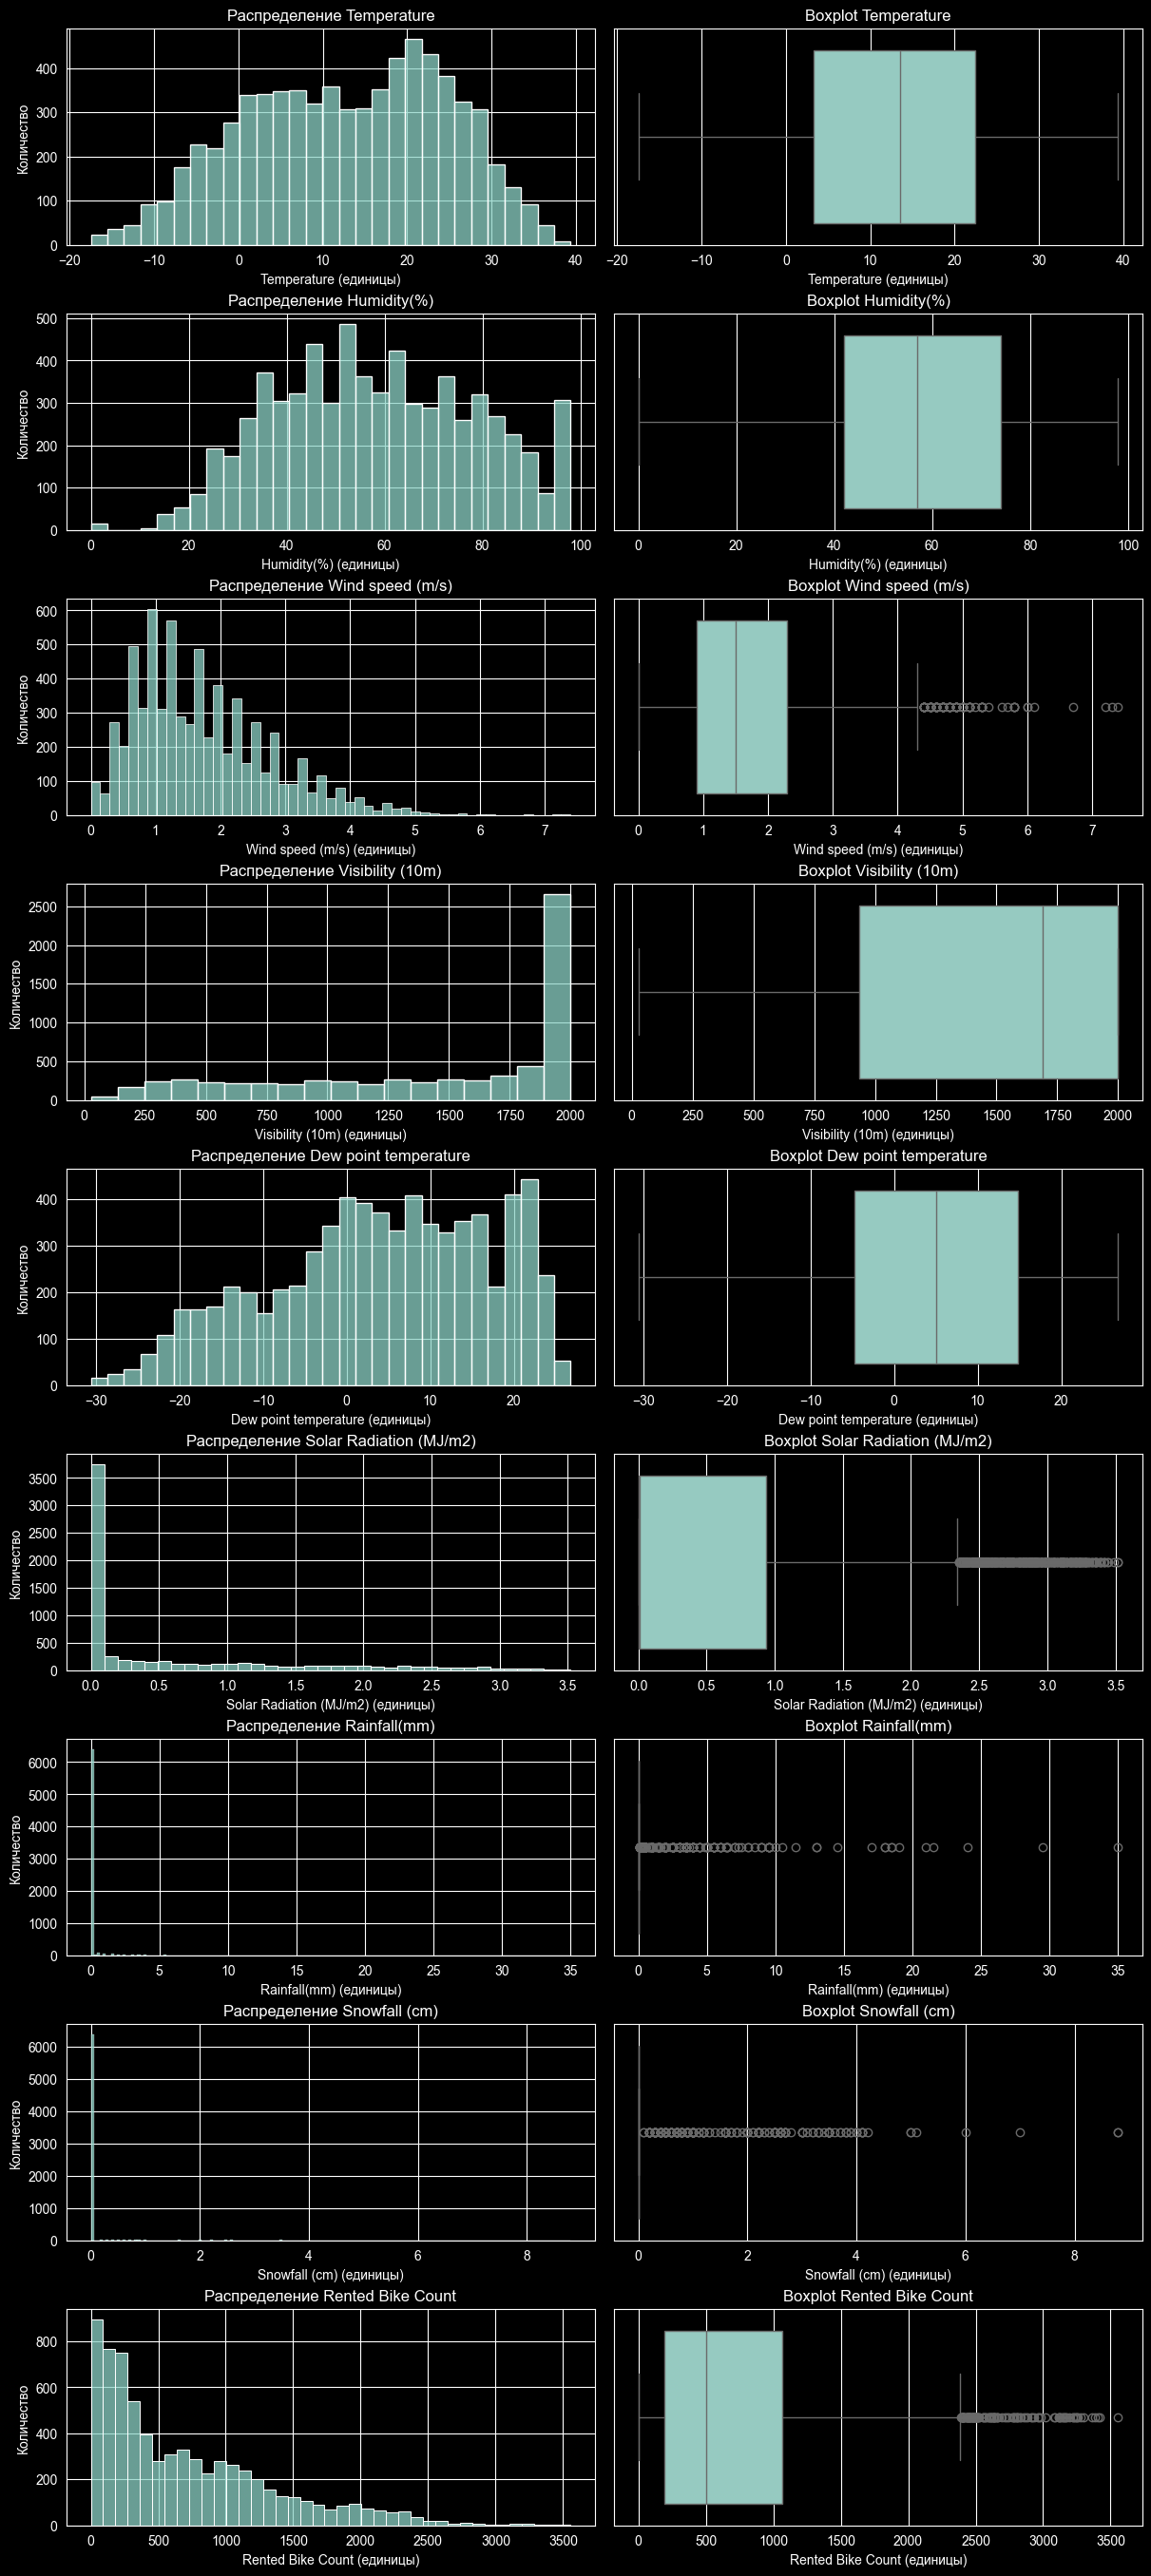

In [34]:
plot_numeric_distributions(df[cols_num])

**Выбросы**
Выбросы заметны у следующих признаков:
- `Wind Speed` - есть случаи порывистого ветра. Это нормально для Сочи, где грозы и шторма нередкость
- `Humidity` - влажность в целом находится в реальных границах от 0 до 98 процентов. Хотя нулевой показатель влажности для приморского города является аномалией и скорее всего 0 - это пропуск или ошибка в замерах и стоит уточнить этот момент у поставщика данных. В рамках этого проекта будем считать нулевую влажность за допустимое значение
- `Solar radiation` - большое количество выбрсоов сосредоточено в диапазоне от ~2.3 до ~3.7. Но эти показатели нормальны для Сочи, где суточная норма солнечной радиации может достигать 25-30 МДж/м² и более. Выбросы на графике получились в следствии большого количества нулевых и околонулевых значений. Они скорее всего вызваны утренними и вечерними замерами, а также замерами в пасмурное время, когда солнечная радиация почти отсутствует
- `Snowfall` - снег в Сочи редкость, поэтому все ненулевые значения на графике считаются за выброс. Но это нормально для Сочи
-  `Rainfall` - дожди в Сочи происходят гораздо чаще чем снегопад, но они кратковременные и с небольшим объемом осадков. Поэтому редкие и сильные дожди считаются на графике за выброс. Но для Сочи это реалистичный график
- `Rented Bike Count` (Таргет) - есть заметные выбросы в районе примерно 2500-3500. Это нормально для дней с высоким спросом

**Распределения**
Несмотря на различия в распределениях признаков, дополнительное приведение их к нормальному распределению не является обязательным. Для алгоритма KNN влияние различий в масштабе устраняется посредством стандартизации признаков (StandardScaler), а для дерева решений форма распределения признаков не оказывает существенного влияния на процесс обучения модели.



### 3.4 Анализ категориальных признаков

Посмотрим на категориальные переменные

Boolean переменные представляют собой закодированный признак `Time Period`. Восстановим его изначальный вид для удобства анализа

In [35]:
# Получение столбцов признака Time Period
cols_bool_ohe = df.select_dtypes('bool').columns.tolist()
cols_bool_ohe

['Time_Period_Evening',
 'Time_Period_Late Evening',
 'Time_Period_Morning',
 'Time_Period_Night']

In [36]:
# Получение маски для недостающего OHE признака
daytime_col_mask = df[cols_bool_ohe].sum(axis=1) == 0
daytime_col_mask[:5]

0    False
1    False
2    False
3    False
4     True
dtype: bool

In [37]:
# Восстановление признака
time_period = pd.DataFrame({'Time period': df[cols_bool_ohe]
    .join(pd.DataFrame({'Time_Period_Daytime': daytime_col_mask}))
    .idxmax(axis=1)
    .str.replace('Time_Period_', '', regex=False)
}, )

Теперь проанализируем категориальные признаки

In [38]:
df_cat = df.select_dtypes(['string']).join(time_period)
df_cat

,Seasons,Holiday,Functioning Day,Time period
0,Autumn,Holiday,Yes,Evening
1,Autumn,No Holiday,Yes,Evening
2,Winter,No Holiday,Yes,Late Evening
3,Winter,No Holiday,Yes,Night
4,Autumn,No Holiday,Yes,Daytime
...,...,...,...,...
7003,Winter,No Holiday,Yes,Evening
7004,Spring,No Holiday,Yes,Night
7005,Autumn,No Holiday,Yes,Morning
7006,Autumn,No Holiday,Yes,Night


In [39]:
# Функция для построения графиков countplot и barplot по данным для категориальных признаков
def plot_categorical_distributions(df, target):
    fig, axes = plt.subplots(
        len(df.columns),
        2,
        figsize=(14, len(df.columns) * 3)
    )

    # если одна колонка
    if len(df.columns) == 1:
        axes = [axes]

    for i, col in enumerate(df.columns):
        data = df.copy()
        data[col] = data[col].fillna('missing')

        # 1. Countplot (частоты)
        sns.countplot(
            data=data,
            x=col,
            ax=axes[i][0]
        )
        axes[i][0].set_title(f'{col} — count')
        axes[i][0].tick_params(axis='x', rotation=30)

        # 2. Barplot (средний target)
        sns.barplot(
            x=df[col],
            y=target,
            errorbar=None,
            ax=axes[i][1]
        )
        axes[i][1].set_title(f'{col} — mean(target)')
        axes[i][1].tick_params(axis='x', rotation=30)

    plt.show()

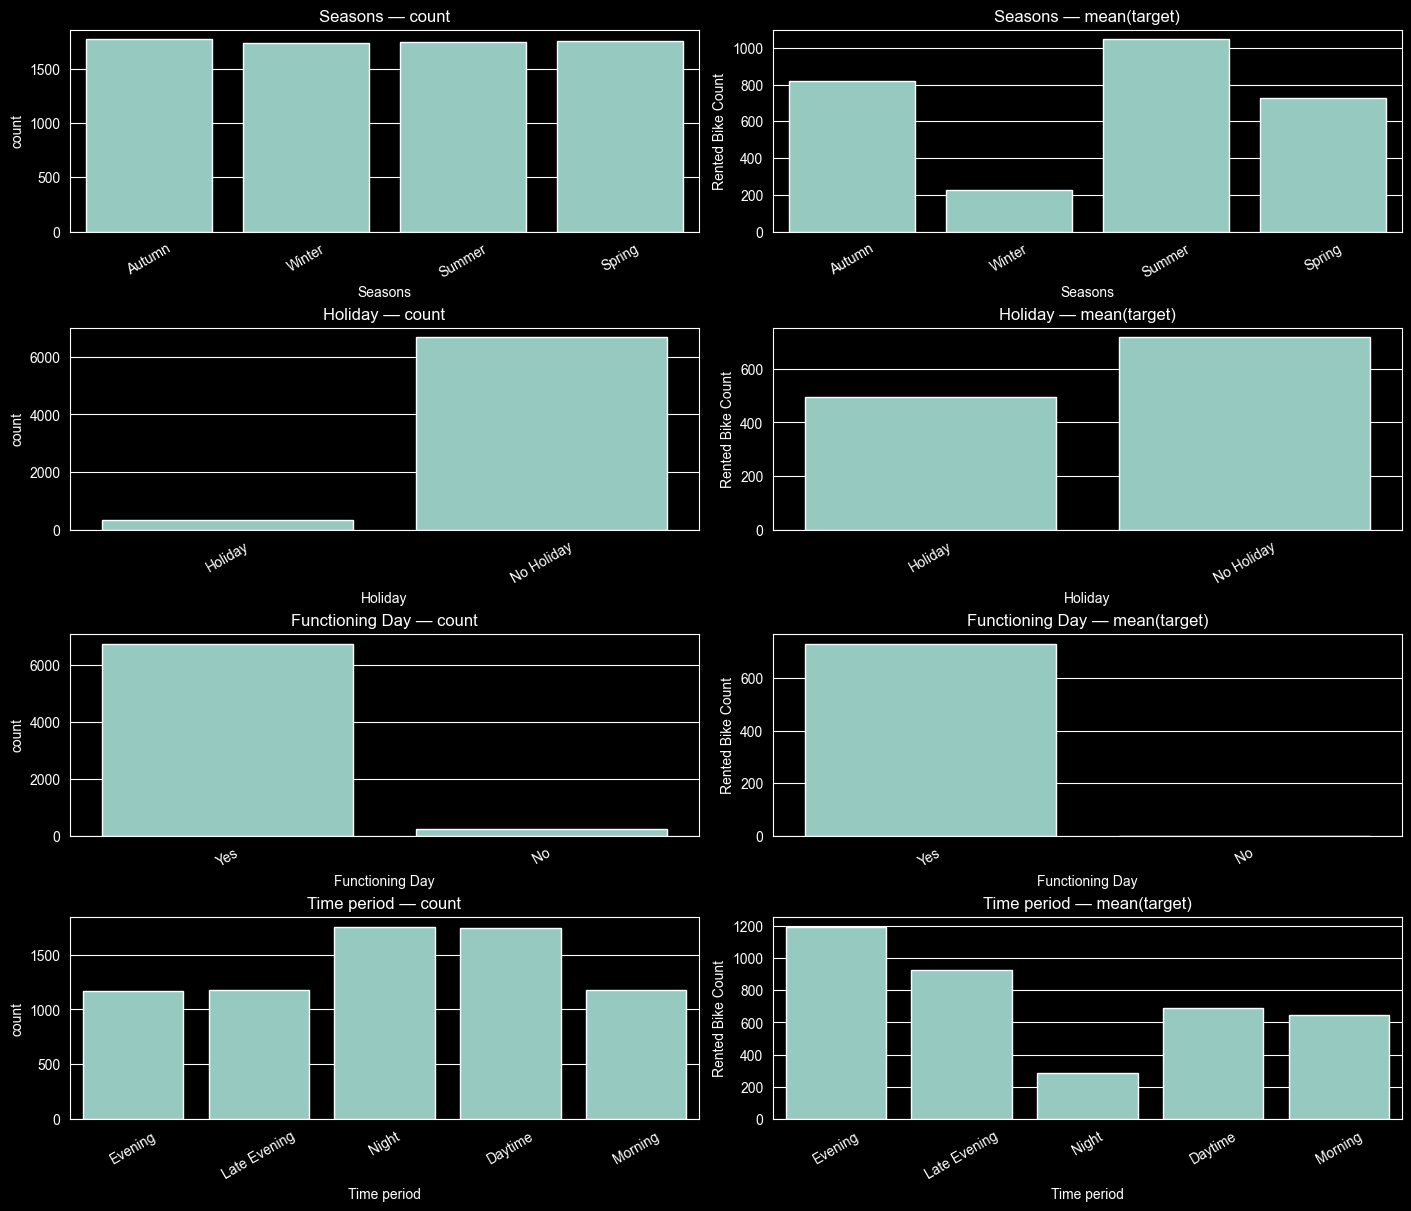

In [40]:
plot_categorical_distributions(df_cat, df[TARGET_COL])

**Распределения**

| Признак             | Распределение по значениям                                  | Среднее значение таргета                                                | Комментарий                                                                                                  |
| ------------------- | ----------------------------------------------------------- | ----------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------ |
| **Seasons**         | Все категории представлены примерно одинаково               | Наибольшее в Summer, затем Autumn, далее Spring, минимальное в Winter   | Сезонность оказывает существенное влияние на спрос: летом арендуют чаще всего, зимой — заметно реже.         |
| **Holiday**         | Наблюдений с No Holiday значительно больше, чем с Holiday   | В No Holiday среднее выше, чем в Holiday                                | В праздничные дни спрос ниже, однако категория Holiday представлена значительно меньшим числом наблюдений.   |
| **Functioning Day** | Почти все наблюдения относятся к Yes                        | При Yes среднее положительное и высокое, при No практически отсутствует | Нерабочие дни исключают аренду велосипедов; признак выглядит очень информативным.                |
| **Time period**     | Night и Daytime представлены чаще, Morning и Evening — реже | Максимум в Evening, затем Late Evening; минимум в Night                 | Наблюдается выраженная внутрисуточная динамика спроса: пик приходится на вечерние часы, минимум — на ночные. |

**Кодирование**
Предусмотрим кодирование признаков, которое реализуем в пайплайне предобработки данных

- Признак `Time period` корректно закодирован с помощью OHE, оставляем его в изначальном виде
- Признак `Seasons` состоит из 4 уникальных значений, для его кодирования лучше всего подойдет OHE
- Признаки `Holiday` и `Functioning Day` закодируем в виде 0/1 в датасете для дальнейшего применения в моделе

В целом все признаки выглядит перспективно для применения в моделях

### 3.5 Корреляции

Оценим корреляции признаков между собой и целевой переменной с помощью phik и тепловой карты

In [41]:
# Функция для построения тепловой карты
def heatmap(df):
    plt.figure(figsize=(20, 15))

    sns.heatmap(
        df,
        cmap="coolwarm",
        vmin=0, vmax=1,
        annot=True, fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8}
    )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.title("Phik Correlation Matrix", fontsize=16)
    plt.show()

# Функция для получения пар признаков со значением их корреляции
def phik_to_pairs(df_phik):
    s = df_phik.stack()
    s = s[s.index.get_level_values(0) != s.index.get_level_values(1)]
    s = s[s.index.get_level_values(0) < s.index.get_level_values(1)]
    s = s.sort_values(ascending=False)
    return s

Для корректного построения phik матрицы требуется определить interval_cols, передав в нее непрерывные числовые признаки. Будем считать таким признаками те, у которых 20 и более уникальных значений

In [42]:
# Вычисление признаков с непрерывными числовыми значениями
DISCRETE_THRESHOLD = 20

continuous_cols = df.columns[df.nunique() > DISCRETE_THRESHOLD].tolist()

continuous_cols

['Temperature',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'Rented Bike Count']

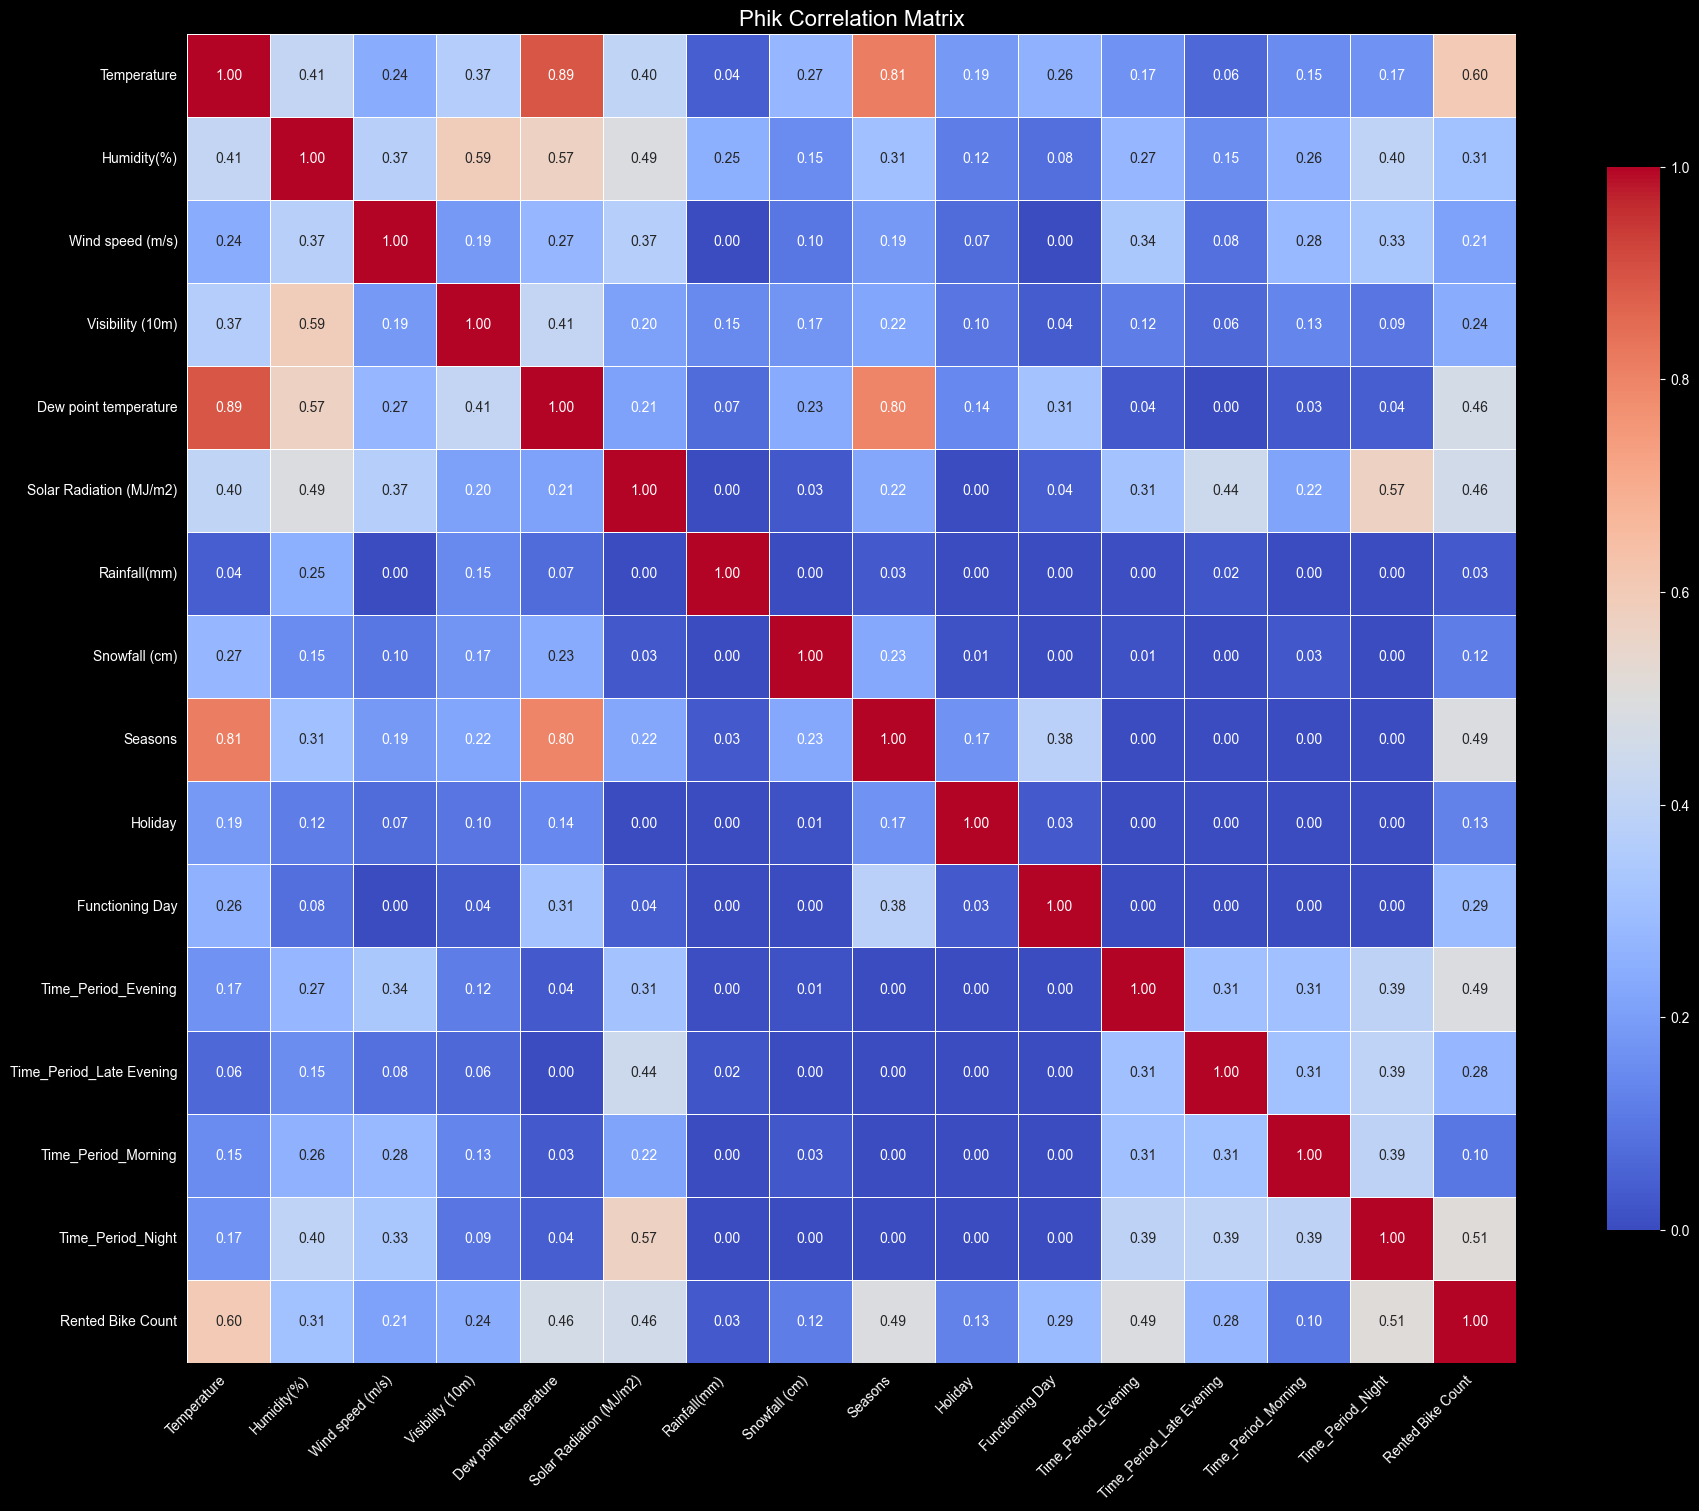

In [43]:
# Построение тепловой карты
df_phik = df.phik_matrix(interval_cols=continuous_cols)
heatmap(df_phik)

Уже хорошо заметны корреляции как признаков между собой, так и с таргетом. Это ожидаемо, так как многие погодные признаки связаны между собой

Посмотрим на корреляцию признаков между собой подробнее

In [44]:
# Топ сильно коррелирующих между собой признаков
phik_to_pairs(df_phik.drop(index=TARGET_COL, columns=TARGET_COL))[:12]

Dew point temperature    Temperature                 0.892561
Seasons                  Temperature                 0.814083
Dew point temperature    Seasons                     0.800099
Humidity(%)              Visibility (10m)            0.587097
Dew point temperature    Humidity(%)                 0.570817
Solar Radiation (MJ/m2)  Time_Period_Night           0.566452
Humidity(%)              Solar Radiation (MJ/m2)     0.490686
Solar Radiation (MJ/m2)  Time_Period_Late Evening    0.440679
Humidity(%)              Temperature                 0.413596
Dew point temperature    Visibility (10m)            0.410392
Solar Radiation (MJ/m2)  Temperature                 0.401338
Humidity(%)              Time_Period_Night           0.397880
dtype: float64

Анализ корреляций показал, что погодные признаки в значительной степени связаны между собой. Особенно сильная корреляция наблюдается между температурой, точкой росы и сезоном (коэффициенты выше 0.8). Это указывает на наличие мультиколлинеарности между частью метеорологических переменных

Для используемых моделей данная особенность имеет различное значение. Для Decision Tree влияние мультиколлинеарности обычно невелико, поскольку дерево самостоятельно выбирает наиболее информативные признаки при разбиениях. Для KNN наличие сильно коррелирующих признаков может быть более заметным, так как расстояния между объектами рассчитываются с учётом всех признаков. В связи с этим удаление части избыточных переменных потенциально может улучшить качество модели за счёт снижения влияния дублирующей информации.

Кроме того, выявленные зависимости открывают возможности для feature engineering. Коррелирующие признаки могут быть объединены в новые, более информативные характеристики, отражающие общие погодные условия. Это позволяет уменьшить избыточность данных, сохранить полезную информацию и в ряде случаев повысить качество и устойчивость моделей.

Выведем отдельно корреляццию с таргетом

In [45]:
# Список признаков в корреляции с таргетом
df_phik.loc[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False).to_frame()

,Rented Bike Count
Temperature,0.603136
Time_Period_Night,0.508885
Seasons,0.491204
Time_Period_Evening,0.489551
Dew point temperature,0.463809
Solar Radiation (MJ/m2),0.456615
Humidity(%),0.308656
Functioning Day,0.288384
Time_Period_Late Evening,0.275677
Visibility (10m),0.241367


**Кореляция с таргетом**
Наибольшую связь с количеством арендованных велосипедов демонстрируют температура (0.60), ночное время суток (0.51), сезон (0.49), вечернее время (0.49), точка росы (0.46) и солнечная радиация (0.46). Это подтверждает, что спрос на велосипеды в первую очередь зависит от погодных условий и временных характеристик. При этом ни один признак не обладает очень высокой корреляцией с целевой переменной, что указывает на влияние совокупности факторов, а не одного доминирующего признака.

### 3.6 Вывод

По итогам EDA можно сделать вывод, что датасет в целом хорошо подготовлен для моделирования спроса на велосипеды. Доля пропусков невелика и может быть обработана в пайплайне без существенной потери информации, явные и неявные дубликаты отсутствуют, а обнаруженные выбросы в погодных показателях и целевой переменной в основном объясняются реальными особенностями наблюдений, а не ошибками данных.

Анализ распределений показал, что спрос на аренду велосипедов заметно зависит от сезона, времени суток, погодных условий и факта работы сервиса. Наиболее высокий спрос наблюдается летом и в вечерние часы, а наиболее низкий - зимой и ночью. Корреляционный анализ дополнительно подтвердил значимость температурных и временных признаков, а также показал наличие связи между рядом погодных переменных, что важно учитывать при построении моделей.

На следующих этапах имеет смысл сосредоточиться на аккуратной обработке пропусков, кодировании категориальных переменных и создании дополнительных признаков, которые помогут лучше отразить погодные и временные закономерности спроса.

## 4. Построение пайплайна предобработки

Создадим пайплайн предобработки признаков, чтобы в дальнейшем применять его перед применением модели. В пайплайн должно войти:
- заполнение пропуском
- нормализация числовых признаков
- корректное кодирование булевых и категориальных признаков


In [46]:
# Создание препроцессора

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer

# Функция вынесена в отдельный файл, так как ее понадобится экспортировать
# вместе с моделью в конце разработки
import features

# Списки колонок вынесены за пределы функции, чтобы далее их можно было менять
# не дублируя весь пайплайн
# Переменные с `_` нужны для сохранения изначального списка признаков.
# Для удобного восстановления списка в процессе работы над ноутбуком

# OHE подходит и для кодирования категориальных признаков с 2 значениями
# Благодаря параметру drop одна из двух полученных колонок будет отброшена и
# Признак станет булевым, закодированным с помощью 0/1
ohe_cols = _ohe_cols = [
    'Seasons',
    'Holiday',
    'Functioning Day'
]
# Для числовых колонок применим заполнение пропусков медианой
# и нормализацию
num_cols = _num_cols = [
    'Temperature',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Dew point temperature',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)'
]
# Эти признаки закодированы с помощью OHE и boolean переменной, но
# модели в данном проекте могут работать только с числами,
# поэтому нужно перевести boolean в числа 0/1
bool_cols = _bool_cols = [
    'Time_Period_Evening',
    'Time_Period_Late Evening',
    'Time_Period_Morning',
    'Time_Period_Night'
]

def get_preprocessor():
    return ColumnTransformer([
            (
                'ohe',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
                    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
                ]),
                ohe_cols
            ),
            (
                'num',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]),
                num_cols
            ),
            (
                'bool',
                Pipeline([
                    # Заполнение пропусков встроено в функцию bool_to_int
                    ('to_int', FunctionTransformer(features.bool_to_int, feature_names_out='one-to-one'))
                ]),
                bool_cols
            )
        ], 
        remainder='drop'
    )

Проверим работу препроцессора

In [47]:
# Проверка работы препроцессора
preprocessor = get_preprocessor()

pd.DataFrame(
    preprocessor.fit_transform(df),
    columns=preprocessor.get_feature_names_out()
)[:5]

,ohe__Seasons_Spring,ohe__Seasons_Summer,ohe__Seasons_Winter,ohe__Holiday_No Holiday,ohe__Functioning Day_Yes,num__Temperature,num__Humidity(%),num__Wind speed (m/s),num__Visibility (10m),num__Dew point temperature,num__Solar Radiation (MJ/m2),num__Rainfall(mm),num__Snowfall (cm),bool__Time_Period_Evening,bool__Time_Period_Late Evening,bool__Time_Period_Morning,bool__Time_Period_Night
0,0.0,0.0,0.0,0.0,1.0,0.627909,-1.159392,0.663053,0.928943,0.021371,-0.108476,-0.123783,-0.167282,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,1.0,1.055624,-0.158090,1.441375,0.928943,0.888437,-0.469643,-0.123783,-0.167282,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,1.0,1.0,-1.653236,-0.959132,-0.115268,0.928943,-1.728109,-0.644402,-0.123783,-0.167282,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,1.0,1.0,-1.510664,-1.059262,0.468473,0.928943,-1.659051,-0.644402,-0.123783,-0.167282,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,1.0,0.887893,-1.209457,0.371183,0.928943,0.197853,2.664358,-0.123783,-0.167282,0.0,0.0,0.0,0.0


Препроцессор для подготовки данных готов. Его можно применять далее в составе пайплайна модели

## 5. Обучение базовых нелинейных моделей

Подготовим данные для тренировки моделей и обучим kNN и Decision Tree


In [48]:
# Отделение таргета от признаков
X = df.drop(columns=TARGET_COL)
y = df[TARGET_COL]

X.shape, y.shape

((7008, 15), (7008,))

Тестовая выборка уже готова и хранится в отдельной переменной. Ее затронем только при подсчете финальных метрик

### 5.1. Обучение kNN Regressor

Обучим и протестируем модель kNN

In [49]:
# Создание пайплайна с моделью kNN
from sklearn.neighbors import KNeighborsRegressor

model_knn = Pipeline([
    ('preprocessor', get_preprocessor()),
    ('model', KNeighborsRegressor(
        n_neighbors=10,
        weights='distance',
        metric='minkowski',
        p=2
    ))
])

In [50]:
# Обучение модели
model_knn.fit(X, y)
,

''

In [52]:
# Оценка модели
from sklearn.model_selection import cross_validate

cv_result = cross_validate(
    model_knn,
    X,
    y,
    cv=cv,
    scoring=scoring
)

add_metrics('knn', cv_result)

### 5.2. Обучение Decision Tree

Обучим и протестируем модель Decision Tree

In [53]:
# Создание пайплайна с моделью Decision Tree
from sklearn.tree import DecisionTreeRegressor

model_dt = Pipeline([
    ('preprocessor', get_preprocessor()),
    ('model', DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=15,
        # max_leaf_nodes=150,
        random_state=RANDOM_STATE
    ))
])

In [54]:
# Обучение модели
model_dt.fit(X, y)
,

''

In [55]:
# Оценка модели
cv_result = cross_validate(
    model_dt,
    X,
    y,
    cv=cv,
    scoring=scoring
)

add_metrics('dt', cv_result)

### 5.3 Метрики моделей

Посмотрим на метрики базовых нелинейных моделей и сравним их с моделью предоставленной клиентом

In [56]:
cv_results

,rmse,mae,r2
model,,,
dt,315.892053,210.406120,0.760953
knn,324.760357,218.943374,0.747201
base_test,411.454458,312.531298,0.586293
base_train,412.499623,309.152519,0.592596


**Промежуточный вывод**

Нелинейные модели на изначальных настройках уже показали хороший прирост качества по всем метрикам относительно базовой линейной модели. Далее попробуем улучшить результат с помощью подбора параметров

## 6. Подбор гиперпараметров с Optuna

Реализуем подбор гиперпараметров с помощью Optuna для улучшения базовых нелинейных моделей

### 6.1. Оптимизация kNN Regressor

Улучшим kNN модель с помощью подбора следующих признаков:
- n_neighbors
- weights
- p (с предустановленным параметром metric='minkowski')


In [57]:
# Инициализация функции для поиска гиперпараметров
from sklearn.model_selection import cross_val_score

def objective(trial: optuna.trial.Trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 50),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p': trial.suggest_int('p', 1, 5)
    }

    model = Pipeline([
        ('preprocessor', get_preprocessor()),
        ('model', KNeighborsRegressor(**params))
    ])

    score = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    ).mean()

    if hasattr(trial, "report"):
        trial.report(score, step=0)

    if hasattr(trial, "should_prune") and trial.should_prune():
        raise optuna.TrialPruned()

    return score

In [58]:
# Запуск исследования
# Фиксируем сид через самплер
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
)
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-06-06 23:40:17,776] A new study created in memory with name: no-name-505522af-809b-4769-ab24-c7f1c006070e


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-06 23:40:22,234] Trial 0 finished with value: -327.7231513438525 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 4}. Best is trial 0 with value: -327.7231513438525.
[I 2026-06-06 23:40:26,012] Trial 1 finished with value: -328.39993250358793 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 5}. Best is trial 0 with value: -327.7231513438525.
[I 2026-06-06 23:40:26,194] Trial 2 finished with value: -325.8259396420198 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'p': 2}. Best is trial 2 with value: -325.8259396420198.
[I 2026-06-06 23:40:26,568] Trial 3 finished with value: -326.93124040276894 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'p': 1}. Best is trial 2 with value: -325.8259396420198.
[I 2026-06-06 23:40:30,502] Trial 4 finished with value: -340.0018665046492 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'p': 3}. Best is trial 2 with value: -325.8259396420198.
[I 2026-06-06 23:40:34,259] Trial 5 pruned

In [59]:
# Вывод результатов
print("Наилучшие гиперпараметры:", study.best_params)
print("Лучшее значение (rmse):", -study.best_value)

Наилучшие гиперпараметры: {'n_neighbors': 13, 'weights': 'distance', 'p': 1}
Лучшее значение (rmse): 316.5196031848937


Сохраним лучшую полученную модель и замерим метрики с помощью кросс валидации

In [60]:
# Сохранение улучшенной модели
best_params_knn = study.best_params

model_knn = Pipeline([
    ('preprocessor', get_preprocessor()),
    ('model', KNeighborsRegressor(**best_params_knn))
])

model_knn.fit(X, y)
,

''

In [61]:
# Оценка модели
cv_result = cross_validate(
    model_knn,
    X,
    y,
    cv=cv,
    scoring=scoring
)

add_metrics('knn_optuna', cv_result)

In [62]:
cv_results

,rmse,mae,r2
model,,,
dt,315.892053,210.406120,0.760953
knn_optuna,316.519603,214.255411,0.759842
knn,324.760357,218.943374,0.747201
base_test,411.454458,312.531298,0.586293
base_train,412.499623,309.152519,0.592596


Модель показа метрики немного лучше изначальных и при этом модель все еще уступает Decision Tree без подбора параметров


### 6.2. Оптимизация Decision Tree Regressor

Подбор параметров для kNN дал незначительный прирост, посмотрим как он сработает для модели Decision Tree Regressor. Будем подбирать следующие признаки:

- max_depth
- min_samples_split
- min_samples_leaf
- max_leaf_nodes


In [63]:
def objective(trial: optuna.trial.Trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 2, 200)
    }

    model = Pipeline([
        ('preprocessor', get_preprocessor()),
        ('model', DecisionTreeRegressor(random_state=RANDOM_STATE, **params))
    ])

    score = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    ).mean()

    if hasattr(trial, "report"):
        trial.report(score, step=0)

    if hasattr(trial, "should_prune") and trial.should_prune():
        raise optuna.TrialPruned()

    return score

In [64]:
# Запуск исследования
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-06-06 23:41:00,958] A new study created in memory with name: no-name-3b27bd12-9d21-47a9-bad5-6174548bc8e5


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-06 23:41:01,456] Trial 0 finished with value: -322.04599513294835 and parameters: {'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_leaf_nodes': 136}. Best is trial 0 with value: -322.04599513294835.
[I 2026-06-06 23:41:01,726] Trial 1 finished with value: -328.32755624073167 and parameters: {'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_leaf_nodes': 49}. Best is trial 0 with value: -322.04599513294835.
[I 2026-06-06 23:41:01,889] Trial 2 finished with value: -318.486802333116 and parameters: {'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 12, 'max_leaf_nodes': 147}. Best is trial 2 with value: -318.486802333116.
[I 2026-06-06 23:41:02,044] Trial 3 finished with value: -320.4440401241706 and parameters: {'max_depth': 10, 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_leaf_nodes': 150}. Best is trial 2 with value: -318.486802333116.
[I 2026-06-06 23:41:02,173] Trial 4 finished with value: -342.83016505357944 and par

In [65]:
# Вывод результатов
print("Наилучшие гиперпараметры:", study.best_params)
print("Лучшее значение (rmse):", -study.best_value)

Наилучшие гиперпараметры: {'max_depth': 11, 'min_samples_split': 13, 'min_samples_leaf': 13, 'max_leaf_nodes': 94}
Лучшее значение (rmse): 314.66646749735446


Сохраним лучшую полученную модель и замерим метрики с помощью кросс валидации

In [66]:
# Сохранение улучшенной модели
best_params_dt = study.best_params
best_params_dt['random_state'] = RANDOM_STATE

model_dt = Pipeline([
    ('preprocessor', get_preprocessor()),
    ('model', DecisionTreeRegressor(**best_params_dt))
])

model_dt.fit(X, y)
,

''

In [67]:
# Оценка модели
cv_result = cross_validate(
    model_dt,
    X,
    y,
    cv=cv,
    scoring=scoring
)

add_metrics('dt_optuna', cv_result)

In [68]:
cv_results

,rmse,mae,r2
model,,,
dt_optuna,314.666467,212.306279,0.762815
dt,315.892053,210.406120,0.760953
knn_optuna,316.519603,214.255411,0.759842
knn,324.760357,218.943374,0.747201
base_test,411.454458,312.531298,0.586293
base_train,412.499623,309.152519,0.592596


Подбор гиперпараметров с помощью Optuna не дал заметного улучшения для DecisionTreeRegressor, потому что исходная модель уже была настроена близко к оптимальной области

## 7. Feature Engineering

Попробуем создать несколько признаков на основе имеющихся данных. Новые признаки должны лучше улавливать комбинацию текущих.

Реализуем следующие признаки:
- Temperature-Humidity Index (ощущаемая температура) - попробуем применить этот индекс для комбинирования признаков влажности и температуры
- Хорошая ли погода - объединим признаки снегопада и дождя

Классы для формирования признаков описаны в файле `features.py`


In [69]:
# Настройка пайплайна с добавлением новых признаков
pipeline_step_fe = ColumnTransformer([
        ('thi', features.THIFeatureCreator(), ["Temperature", "Humidity(%)"]),
        ('good_weather', features.GoodWeatherFeatureCreator(), ["Rainfall(mm)", "Snowfall (cm)"])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform = 'pandas')

In [70]:
# Добавление новых колонок в список для корректной работы препроцессора
num_cols = _num_cols + ["THI", "Good_Weather"]
num_cols

['Temperature',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'THI',
 'Good_Weather']

In [71]:
# Добавление признаков в kNN модель
model_knn_fe = Pipeline([
    ('fe', pipeline_step_fe),
    ('preprocessor', get_preprocessor()),
    ('model', KNeighborsRegressor(**best_params_knn))
])

model_knn_fe.fit(X, y)

# Оценка модели
cv_result = cross_validate(
    model_knn_fe,
    X,
    y,
    cv=cv,
    scoring=scoring
)

add_metrics('knn_optuna_fe', cv_result, True)

In [72]:
# Добавление признаков в Decision Tree модель
model_dt_fe = Pipeline([
    ('fe', pipeline_step_fe),
    ('preprocessor', get_preprocessor()),
    ('model', DecisionTreeRegressor(**best_params_dt))
])
model_dt_fe.fit(X, y)

# Оценка модели
cv_result = cross_validate(
    model_dt_fe,
    X,
    y,
    cv=cv,
    scoring=scoring
)

add_metrics('dt_optuna_fe', cv_result, True)

In [73]:
# Вывод таблицы результатов
cv_results

,rmse,mae,r2
model,,,
knn_optuna_fe,309.538410,207.852765,0.770296
dt_optuna,314.666467,212.306279,0.762815
dt,315.892053,210.406120,0.760953
knn_optuna,316.519603,214.255411,0.759842
dt_optuna_fe,318.970050,212.538094,0.756300
knn,324.760357,218.943374,0.747201
base_test,411.454458,312.531298,0.586293
base_train,412.499623,309.152519,0.592596


**Промежуточный вывод**
Добавление новых признаков незначительно повлияло на модели. Для kNN метрики немного улучшились, для Decision Tree ухудшились. Сохраним обновленную модель для kNN, а для DT попробуем пойти от обратного и убрать часть признаков из моделей

In [74]:
# Сохранение модели kNN после создания признаков
model_knn = model_knn_fe

In [75]:
# Восстановление изначального списка числовых признаков
num_cols = _num_cols

## 8. Отбор признаков

Для отбора признаков встроим в пайплайн обучения модели этап с `RFECV`. Данный класс рекурсивно отбирает признаки и подсчитывает метрики с помощью кросс-валидации

Его удобно использовать с Decision Tree, потому что эта модель может возвращать важность признаков, на основе которой и работает RFECV

In [76]:
# Функция для формирования RFECV
from sklearn.feature_selection import RFECV

def get_feature_selector(estimator):
    return RFECV(
        estimator=estimator,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        min_features_to_select=5
    )

In [77]:
# Пайплайн для отбора признаков
model_dt_fs = Pipeline([
    ('preprocessor', get_preprocessor()),
    ('feature_selector', get_feature_selector(
        estimator=DecisionTreeRegressor(**best_params_dt),
    )),
    ('model', DecisionTreeRegressor(**best_params_dt))
])

In [78]:
# Запуск обучения модели с отбором признаков
model_dt_fs.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardSca...
                 RFECV(cv=KFold(n_splits=5, random_state=1703, shuffle=True),
                       estimator=DecisionTreeRegressor(max_depth=11,
                                                       max_leaf_nodes=94,
                                                       min_samples_leaf=13,
                                                       min_samples_split=13,
                                                       random_state=1703),
                       min_features_to_select=5, n_jobs=-1,
                       scoring='neg_root_mean_squared_error')),
                ('model',
                 DecisionTreeRegressor(max_depth=11, max_leaf_nodes=94,
                                       min_samples_leaf=13,
                                       min_samples_split=13,
                                       random_state=1703))])

In [79]:
# Вспомогательные функции для получения имен отобранных признаков
def get_selected_feautres(pipeline):
    selected_features = (
        pipeline
        .named_steps['preprocessor']
        .get_feature_names_out()
    )[pipeline.named_steps['feature_selector'].support_].tolist()

    return sorted(selected_features)

def get_unselected_feautres(pipeline):
    selected_features = (
        pipeline
        .named_steps['preprocessor']
        .get_feature_names_out()
    )[~pipeline.named_steps['feature_selector'].support_].tolist()

    return sorted(selected_features)

In [80]:
# Получение признаков, которые были отобраны
print(f"Общее число признаков: {len(model_dt_fs.named_steps['preprocessor'].get_feature_names_out())}")
print(f"Количество отобранных признаков: {len(get_selected_feautres(model_dt_fs))}")

print(f"Убранные признаки: {get_unselected_feautres(model_dt_fs)}")

Общее число признаков: 17
Количество отобранных признаков: 12
Убранные признаки: ['num__Snowfall (cm)', 'num__Visibility (10m)', 'num__Wind speed (m/s)', 'ohe__Holiday_No Holiday', 'ohe__Seasons_Summer']


Как и оговаривалось ранее среди признаков есть множество коррелирующих между собой. Поэтому часть погодных признаков была отброшена

Скорее всего сильный дисбаланс классов в признаке Holiday повлиял на его удаление из оптимальной модели

In [81]:
# Оценка модели
cv_result = cross_validate(
    model_dt_fs,
    X,
    y,
    cv=cv,
    scoring=scoring
)

add_metrics('dt_optuna_fs', cv_result)

In [82]:
cv_results

,rmse,mae,r2
model,,,
knn_optuna_fe,309.538410,207.852765,0.770296
dt_optuna,314.666467,212.306279,0.762815
dt,315.892053,210.406120,0.760953
dt_optuna_fs,316.428659,213.656486,0.760124
knn_optuna,316.519603,214.255411,0.759842
dt_optuna_fe,318.970050,212.538094,0.756300
knn,324.760357,218.943374,0.747201
base_test,411.454458,312.531298,0.586293
base_train,412.499623,309.152519,0.592596


Отбор признаков дал минимальный прирост для модели DT. Но после изменения признаков, стоит повторить подбор гиперпараметров

## 9. Повторный подбор гиперпараметров

После отбора признаков нужно повторить подбор гиперпараметров, так как оптимальные значения могли измениться. И повторный подбор более подходящих параметров может дать дополнительное уменьшение ошибки.

### 9.1. Оптимизация kNN Regressor

In [83]:
# Добавление новых колонок в список для корректной работы препроцессора
num_cols = _num_cols + ["THI", "Good_Weather"]
num_cols

['Temperature',
 'Humidity(%)',
 'Wind speed (m/s)',
 'Visibility (10m)',
 'Dew point temperature',
 'Solar Radiation (MJ/m2)',
 'Rainfall(mm)',
 'Snowfall (cm)',
 'THI',
 'Good_Weather']

In [84]:
# Инициализация функции для поиска гиперпараметров
from sklearn.model_selection import cross_val_score

def objective(trial: optuna.trial.Trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 50),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p': trial.suggest_int('p', 1, 5)
    }

    model = Pipeline([
        ('fe', pipeline_step_fe),
        ('preprocessor', get_preprocessor()),
        ('model', KNeighborsRegressor(**params))
    ])

    score = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    ).mean()

    if hasattr(trial, "report"):
        trial.report(score, step=0)

    if hasattr(trial, "should_prune") and trial.should_prune():
        raise optuna.TrialPruned()

    return score

In [85]:
# Запуск исследования

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
)
study.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-06-06 23:41:21,396] A new study created in memory with name: no-name-cfe589b5-1dd1-4d53-a669-080f6a390df9


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-06 23:41:26,517] Trial 0 finished with value: -341.8837275623685 and parameters: {'n_neighbors': 21, 'weights': 'uniform', 'p': 5}. Best is trial 0 with value: -341.8837275623685.
[I 2026-06-06 23:41:30,798] Trial 1 finished with value: -322.556517398874 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 5}. Best is trial 1 with value: -322.556517398874.
[I 2026-06-06 23:41:31,047] Trial 2 finished with value: -337.00417134846657 and parameters: {'n_neighbors': 29, 'weights': 'uniform', 'p': 2}. Best is trial 1 with value: -322.556517398874.
[I 2026-06-06 23:41:35,505] Trial 3 finished with value: -363.1405996745319 and parameters: {'n_neighbors': 47, 'weights': 'uniform', 'p': 5}. Best is trial 1 with value: -322.556517398874.
[I 2026-06-06 23:41:39,838] Trial 4 finished with value: -347.81886522692946 and parameters: {'n_neighbors': 47, 'weights': 'distance', 'p': 4}. Best is trial 1 with value: -322.556517398874.
[I 2026-06-06 23:41:40,098] Trial 5 finished wi

In [86]:
# Вывод результатов
print("Предыдущие наилучшие параметры гиперпараметры:", best_params_knn)
print("Наилучшие гиперпараметры:", study.best_params)

print("Лучшее значение (rmse):", -study.best_value)

Предыдущие наилучшие параметры гиперпараметры: {'n_neighbors': 13, 'weights': 'distance', 'p': 1}
Наилучшие гиперпараметры: {'n_neighbors': 15, 'weights': 'distance', 'p': 1}
Лучшее значение (rmse): 310.73661454045936


Модель стала незначительно хуже во время оптимизации через optuna. Замерим ее финальную метрику через кросс-валидацтю и запишем в общую таблицу

In [87]:
# Добавление признаков в kNN модель
model_knn_fe = Pipeline([
    ('fe', pipeline_step_fe),
    ('preprocessor', get_preprocessor()),
    ('model', KNeighborsRegressor(**study.best_params))
])

model_knn_fe.fit(X, y)

# Оценка модели
cv_result = cross_validate(
    model_knn_fe,
    X,
    y,
    cv=cv,
    scoring=scoring
)

add_metrics('knn_fe_optuna', cv_result, True)

cv_results

,rmse,mae,r2
model,,,
knn_optuna_fe,309.538410,207.852765,0.770296
knn_fe_optuna,310.736615,209.013483,0.768485
dt_optuna,314.666467,212.306279,0.762815
dt,315.892053,210.406120,0.760953
dt_optuna_fs,316.428659,213.656486,0.760124
knn_optuna,316.519603,214.255411,0.759842
dt_optuna_fe,318.970050,212.538094,0.756300
knn,324.760357,218.943374,0.747201
base_test,411.454458,312.531298,0.586293


Модель на кросс-валидации показала результат на уровне kNN модели без создания признаков и повторного подбора параметров. Лучшей kNN моделью остается вариант с оптимизацией через optuna и созданием двух новых признаков.




In [88]:
# Восстановление изначального списка числовых признаков
num_cols = _num_cols

### 9.2. Оптимизация Decision Tree

Отбор признаков немного ухудшил показатель rmse в Decision Tree. Посмотрим, исправит ли это повторная оптимизация

Для более корректного совмещение отбора признаков с оптимизацией попробуем применить подбор гиперпараметров одновременно и для отбора признаков и для самой модели. Это должно позволить найти наиболее оптимальную комбинацию, хотя и потребует больше времени

Попробуем ускорить процесс подбора гиперпараметров с помощью кеширования пайплайна. Если какой-то из этапов пайплайна повторно запустится с одинаковыми гиперпараметрами, то результат работы будет извлечен из кеша


In [89]:
# Объект memory для кеширования пайплайнов, пригодится далее
from joblib import Memory

memory = Memory("./cache", verbose=0)

In [90]:
def suggest_tree_params(trial, suffix=""):
    return {
        "max_depth": trial.suggest_int(f"max_depth{suffix}", 2, 15),
        "min_samples_split": trial.suggest_int(f"min_samples_split{suffix}", 2, 20),
        "min_samples_leaf": trial.suggest_int(f"min_samples_leaf{suffix}", 1, 15),
        "max_leaf_nodes": trial.suggest_int(f"max_leaf_nodes{suffix}", 2, 200),
        "random_state": RANDOM_STATE,
    }

def extract_tree_params(params, suffix=""):
    return {
        "max_depth": params[f"max_depth{suffix}"],
        "min_samples_split": params[f"min_samples_split{suffix}"],
        "min_samples_leaf": params[f"min_samples_leaf{suffix}"],
        "max_leaf_nodes": params[f"max_leaf_nodes{suffix}"],
        "random_state": RANDOM_STATE,
    }

In [91]:
def objective(trial: optuna.trial.Trial):
    params_fs = suggest_tree_params(trial, "_fe")
    params = suggest_tree_params(trial)

    model = Pipeline([
        ('preprocessor', get_preprocessor()),
        ('feature_selector', get_feature_selector(
            estimator=DecisionTreeRegressor(**params_fs),
        )),
        ('model', DecisionTreeRegressor(**params))
    ], memory=memory)

    score = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='neg_root_mean_squared_error'
    ).mean()

    if hasattr(trial, "report"):
        trial.report(score, step=0)

    if hasattr(trial, "should_prune") and trial.should_prune():
        raise optuna.TrialPruned()

    return score

In [92]:
# Запуск исследования
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

[I 2026-06-06 23:42:30,432] A new study created in memory with name: no-name-f4a3273f-3677-44b1-b4a7-1213c5786534


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-06 23:42:30,728] Trial 0 finished with value: -328.12429507814034 and parameters: {'max_depth_fe': 14, 'min_samples_split_fe': 3, 'min_samples_leaf_fe': 15, 'max_leaf_nodes_fe': 92, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_leaf_nodes': 166}. Best is trial 0 with value: -328.12429507814034.
[I 2026-06-06 23:42:30,940] Trial 1 finished with value: -477.84421865631793 and parameters: {'max_depth_fe': 2, 'min_samples_split_fe': 12, 'min_samples_leaf_fe': 12, 'max_leaf_nodes_fe': 139, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 13, 'max_leaf_nodes': 143}. Best is trial 0 with value: -328.12429507814034.
[I 2026-06-06 23:42:31,162] Trial 2 finished with value: -424.7690073038847 and parameters: {'max_depth_fe': 11, 'min_samples_split_fe': 6, 'min_samples_leaf_fe': 13, 'max_leaf_nodes_fe': 65, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_leaf_nodes': 130}. Best is trial 0 with value: -328.12429507814034.
[I 2026-06-0

In [93]:
# Вывод результатов
print("Наилучшие гиперпараметры:", study.best_params)
print("Лучшее значение (rmse):", -study.best_value)

Наилучшие гиперпараметры: {'max_depth_fe': 13, 'min_samples_split_fe': 17, 'min_samples_leaf_fe': 9, 'max_leaf_nodes_fe': 70, 'max_depth': 12, 'min_samples_split': 11, 'min_samples_leaf': 13, 'max_leaf_nodes': 138}
Лучшее значение (rmse): 314.593021525565


In [94]:
# Оценка модели с кросс-валидацией
model_dt_fs_optuna = Pipeline([
    ('preprocessor', get_preprocessor()),
    ('feature_selector', get_feature_selector(
        estimator=DecisionTreeRegressor(**extract_tree_params(study.best_params, '_fe')),
    )),
    ('model', DecisionTreeRegressor(**extract_tree_params(study.best_params)))
], memory=memory)

model_dt_fs_optuna.fit(X, y)

# Оценка модели
cv_result = cross_validate(
    model_dt_fs_optuna,
    X,
    y,
    cv=cv,
    scoring=scoring
)

add_metrics('dt_fs_optuna', cv_result)

In [95]:
cv_results

,rmse,mae,r2
model,,,
knn_optuna_fe,309.538410,207.852765,0.770296
knn_fe_optuna,310.736615,209.013483,0.768485
dt_fs_optuna,314.593022,209.820228,0.762961
dt_optuna,314.666467,212.306279,0.762815
dt,315.892053,210.406120,0.760953
dt_optuna_fs,316.428659,213.656486,0.760124
knn_optuna,316.519603,214.255411,0.759842
dt_optuna_fe,318.970050,212.538094,0.756300
knn,324.760357,218.943374,0.747201


Отбор признаков встроенный в пайплайн Decision Tree не улучшил качество. И на самом деле это ожидаемое поведение. Дерево решений само по себе уже отбрасывает ненужные признаки

## 10. Сравнение лучших моделей

Для финального сравнения выберем лучшие модели внутри каждого семейства алгоритмов:
- `knn_optuna_fe` - среди kNN моделей
- `dt_optuna` - среди DT моделей

Сохраним их в переменные и сделаем вывод почему именно они показали лучшие результаты

Среди DT моделей еще может лучше себя показать `dt_fs_optuna`. Но разрым с вариантом без отбора признаков настолько низок, что мы отбросим этот шаг

In [96]:
# Воссоздание лучших моделей
num_cols = _num_cols + ["THI", "Good_Weather"]

model_knn = Pipeline([
    ('fe', pipeline_step_fe),
    ('preprocessor', get_preprocessor()),
    ('model', KNeighborsRegressor(**best_params_knn))
])
model_knn.fit(X, y)

num_cols = _num_cols

model_dt = Pipeline([
    ('preprocessor', get_preprocessor()),
    ('model', DecisionTreeRegressor(**best_params_dt))
])
model_dt.fit(X, y)
,

''

In [101]:
# Вывод результатов лучших моделей
cv_results.loc[['knn_optuna_fe', 'dt_optuna']]

,rmse,mae,r2
model,,,
knn_optuna_fe,309.538410,207.852765,0.770296
dt_optuna,314.666467,212.306279,0.762815


**Сравнение лучших моделей**

Для итогового сравнения были выбраны `knn_optuna_fe` как лучшая модель среди `KNeighborsRegressor` и `dt_optuna` как лучшая модель среди `DecisionTreeRegressor`. Первая модель использует гиперпараметры, подобранные через Optuna, и дополнительные признаки `THI` и `Good_Weather`. Вторая модель - `DecisionTreeRegressor` с гиперпараметрами, подобранными через Optuna.

Лучший результат показала модель `knn_optuna_fe`. Вероятно, kNN лучше использует локальные зависимости в данных о спросе на велосипеды, а добавленные погодные признаки помогли точнее описать близость объектов. `DecisionTreeRegressor` тоже показал сильный результат, но для него добавление новых признаков и дальнейшие усложнения пайплайна не дали прироста, так как дерево и без того хорошо выделяет важные разбиения.

В качестве лучшей модели для дальнейшей финальной проверки берем `model_knn`.

## 11. Финальная проверка лучшей модели на тестовой выборке

Проверим итоговую kNN модель на тестовой выборке. Это позволит получить финальный результат на реальных данных и убедиться в отсутствии переобучения


In [98]:
X_test = df_test.drop(columns=TARGET_COL)
y_test = df_test[TARGET_COL]

In [99]:
# Оценка лучшей модели kNN

y_pred = model_knn.predict(X_test)

# Метрики
test_result = pd.DataFrame({
    'rmse': [mean_squared_error(y_test, y_pred) ** 0.5],
    'mae': [mean_absolute_error(y_test, y_pred)],
    'r2': [r2_score(y_test, y_pred)]
}, index=['test']).T

result = pd.concat([
    test_result,
    cv_results.loc['knn_optuna_fe'].T
], axis=1)

result.columns = ['test', 'train']

result

,test,train
rmse,301.062379,309.538410
mae,203.448454,207.852765
r2,0.778506,0.770296


Модель kNN хорошо показала себя на тесте, итоговые метрики даже немного лучше чем на тренировочных данных

## 12. Интерпретация результатов и важность признаков

Для модели `kNN` нельзя получить встроенную важность признаков напрямую, потому что у нее нет коэффициентов или `feature_importances_`. Однако этот пункт можно корректно выполнить с помощью `permutation_importance`: если после случайного перемешивания значений признака качество модели заметно ухудшается, значит признак действительно важен для прогноза.

Такой подход особенно полезен здесь, потому что лучшей моделью стала `kNN` с дополнительными признаками `THI` и `Good_Weather`. Ниже оценим важность всех признаков финальной модели по тому, насколько их перемешивание ухудшает `RMSE`.

In [103]:
from sklearn.inspection import permutation_importance
from IPython.display import Markdown, display

X_test_fe = model_knn.named_steps['fe'].transform(X_test)

knn_feature_model = Pipeline([
    ('preprocessor', model_knn.named_steps['preprocessor']),
    ('model', model_knn.named_steps['model'])
])

perm_result = permutation_importance(
    knn_feature_model,
    X_test_fe,
    y_test,
    scoring='neg_root_mean_squared_error',
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_importance = (
    pd.DataFrame({
        'feature': X_test_fe.columns,
        'importance_mean': perm_result.importances_mean,
        'importance_std': perm_result.importances_std,
    })
    .sort_values('importance_mean', ascending=False)
    .reset_index(drop=True)
)

feature_importance['importance_mean'] = feature_importance['importance_mean'].round(3)
feature_importance['importance_std'] = feature_importance['importance_std'].round(3)

feature_importance

,feature,importance_mean,importance_std
0,Functioning Day,53.556,2.494
1,Solar Radiation (MJ/m2),52.004,3.922
2,Good_Weather,48.300,5.480
3,Time_Period_Evening,47.725,3.645
4,Seasons,34.959,3.863
5,Time_Period_Late Evening,32.382,2.700
6,Humidity(%),30.017,3.648
7,Time_Period_Night,25.993,3.952
8,Temperature,20.100,3.476
9,THI,17.612,3.161


Наибольшее влияние на качество финальной kNN-модели оказывают признаки: Functioning Day, Solar Radiation (MJ/m2), Good_Weather, Time_Period_Evening, Seasons.

Чем выше значение importance_mean, тем сильнее ухудшается качество модели при перемешивании признака, а значит тем важнее этот признак для прогноза.

Все признаки показали положительный вклад в качество модели, но их влияние заметно различается по силе.
Сконструированные признаки вошли в число наиболее важных, что подтверждает пользу feature engineering

## 13. Подготовка финального пайплайна и артефактов модели

Сохраним лучшую модель `kNN` вместе с краткими метаданными в файл `model.joblib`, затем загрузим артефакт обратно и проверим, что качество после десериализации совпадает с исходным. Такой формат удобно передавать в отдельный ноутбук или в production-процесс без повторного обучения модели.

In [110]:
# Экспорт модели и метаданных в файл
from datetime import datetime

# Подготовка метаданных
metadata = {
    'model_version': '1.0',
    'training_date': datetime.now().strftime('%Y-%m-%d'),
    'rmse': float(result.loc['rmse', 'test']),
}

print(metadata)

joblib.dump({
    'model': model_knn,
    'metadata': metadata
}, 'model.joblib')

{'model_version': '1.0', 'training_date': '2026-06-07', 'rmse': 301.0623793001815}


['model.joblib']

In [111]:
# Импорт модели и метаданных из файла
artifact_loaded = joblib.load('model.joblib')

model_loaded = artifact_loaded['model']
metadata_loaded = artifact_loaded['metadata']

y_pred = model_loaded.predict(X_test)

print(
    'RMSE загруженной модели: ',
    mean_squared_error(y_test, y_pred) ** 0.5
)

# Пример доступа к метаданным
print('Метаданные модели', metadata_loaded)

RMSE загруженной модели:  301.0623793001815
Метаданные модели {'model_version': '1.0', 'training_date': '2026-06-07', 'rmse': 301.0623793001815}


Модель корректрно экспортирована, импортирована и повторно применена. Метрика rmse у загруженной модели совпадает с изначальной

## 14. Итоговые выводы и рекомендации для BikeSouth

**Итоги моделирования**

Baseline-линейная регрессия показала RMSE около 413 и R2 около 0.59, поэтому для проекта был заметный запас на улучшение. Обе нелинейные модели превзошли baseline: лучшим решением оказался `KNeighborsRegressor` с подбором гиперпараметров через Optuna и дополнительными признаками `THI` и `Good_Weather`.

На кросс-валидации лучшая kNN-модель получила `RMSE = 309.54`, `MAE = 207.85`, `R2 = 0.770`. На тестовой выборке модель показала `RMSE = 301.06`, `MAE = 203.45`, `R2 = 0.779`, то есть сохранила высокое качество и уверенно превзошла baseline. Для `DecisionTreeRegressor` качество на обучении также было высоким, однако модель уступила kNN

**Практические выводы для BikeSouth**

В рамках текущей модели спрос на велосипеды сильнее всего связан с доступностью сервиса (`Functioning Day`), солнечной радиацией, отсутствием осадков, временем суток и сезоном. При этом в реальном спросе могут присутствовать более сложные взаимодействия факторов, которые модель отражает лишь частично. Это означает, что для операционного планирования особенно важно учитывать не только календарные признаки, но и погодные сочетания, влияющие на комфорт поездки.

Рекомендуется использовать сохраненный `model.joblib` как основной артефакт прогноза, обновлять модель по мере накопления новых данных и в следующей итерации проекта попробовать применить более комплексные модели